In [443]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import re

In [444]:
df = pd.read_csv("../csv/used_cars.csv")

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


#### Visualizamos las columnas que tienen campos nulos, para poder tratarlos de la forma correcta.

In [445]:
df_copy = df.copy()

df_copy.isna().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

<Axes: >

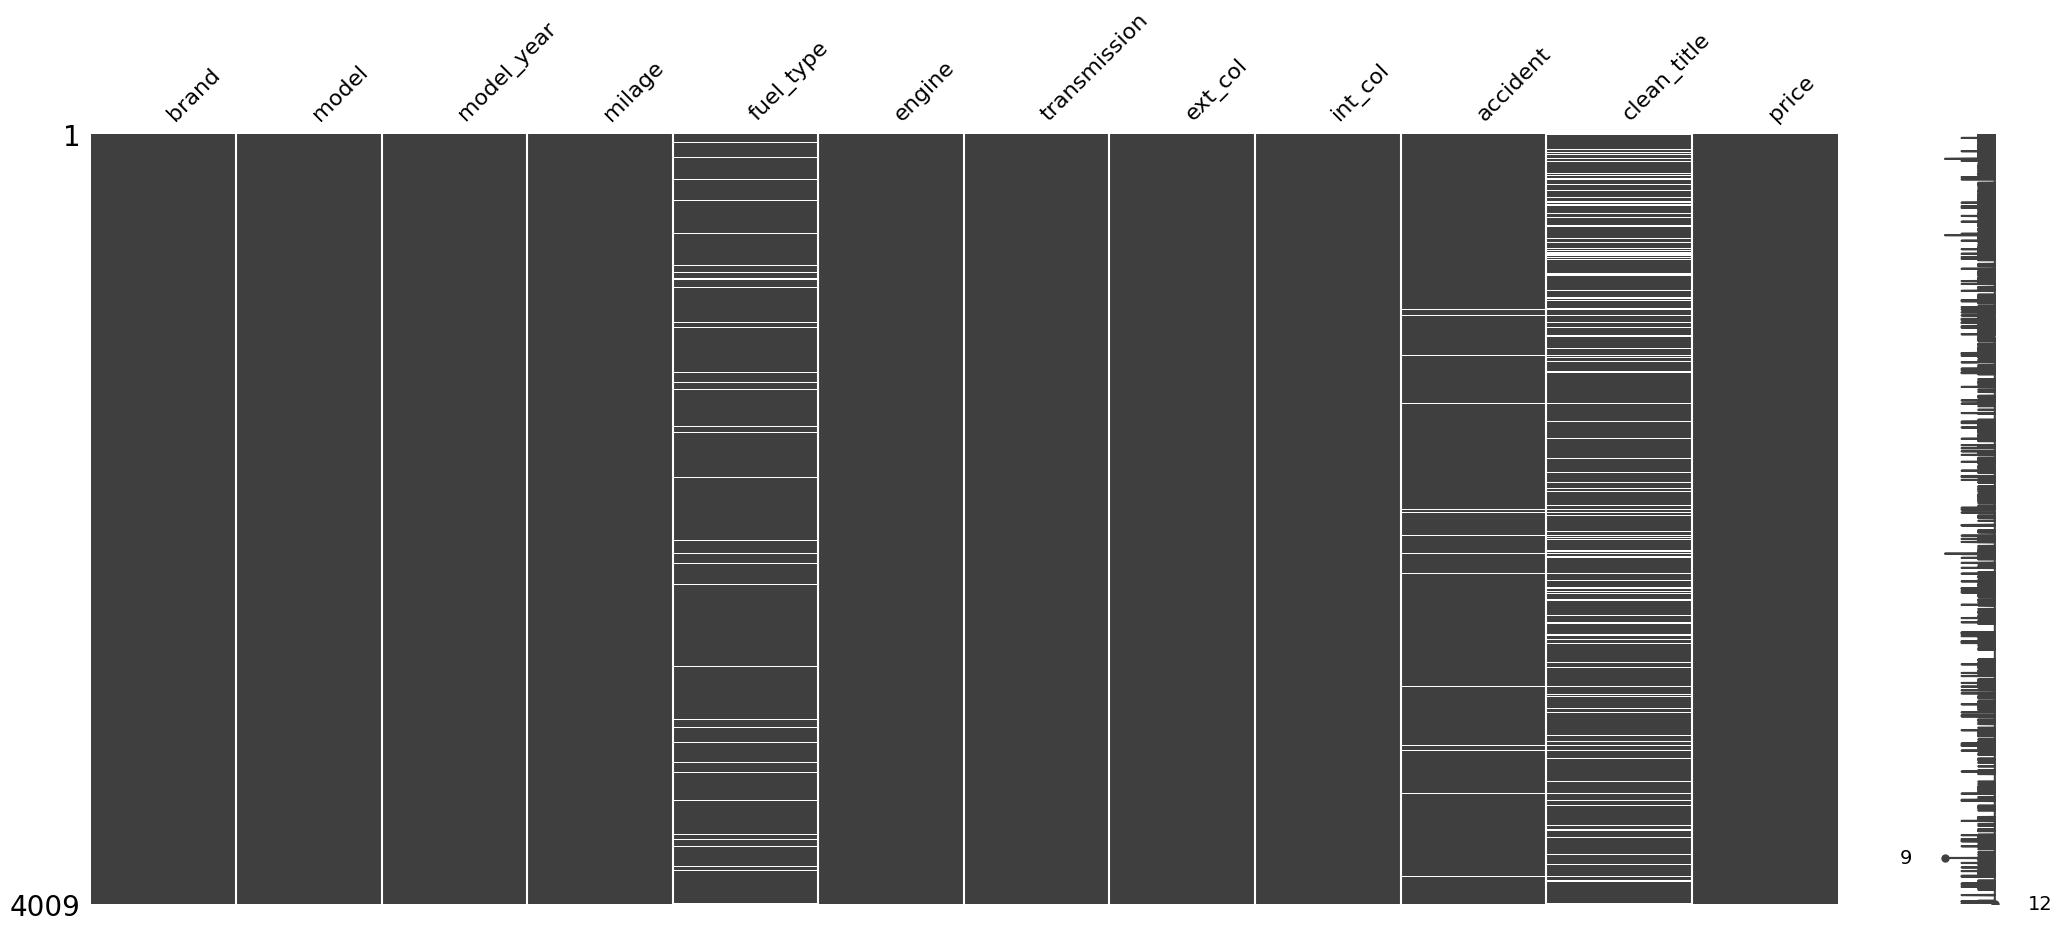

In [446]:
msno.matrix(df_copy)

#### Decidimos que no debemos eliminar los campos nulos de la colummna 'clean_title'. En lugar de eso cambiamos los valores vacíos por 'No', ya que el resto de campos esta rellenos con Yes, por lo que se entiende que los campos faltante no han sido recogidos con el valor correcto.

In [447]:
df_copy["clean_title"] = df_copy["clean_title"].fillna("No")

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   4009 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


#### Eliminamos el resto de campos nulos que quedan en nuestro dataset.

In [448]:
df_copy = df_copy.dropna()

df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3730 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         3730 non-null   object
 1   model         3730 non-null   object
 2   model_year    3730 non-null   int64 
 3   milage        3730 non-null   object
 4   fuel_type     3730 non-null   object
 5   engine        3730 non-null   object
 6   transmission  3730 non-null   object
 7   ext_col       3730 non-null   object
 8   int_col       3730 non-null   object
 9   accident      3730 non-null   object
 10  clean_title   3730 non-null   object
 11  price         3730 non-null   object
dtypes: int64(1), object(11)
memory usage: 378.8+ KB


#### Normalización del campo 'transmission', muchos campos con el mismo valor pero escrito de distinta forma.

In [449]:
# Seleccionamos valores que queremos reemplazar y le asignamos el valor por el que deben ser reemplazados
mapping = {
    '10-Speed A/T': '10-Speed Automatic',
    'Atuomatic, 10-Spd': '10-Speed Automatic',

    '4-Speed A/T': '4-Speed Automatic',
    '5-Speed A/T': '5-Speed Automatic',
    '6-Speed A/T': '6-Speed Automatic',

    '6-Speed Mt': '6-Speed Manual',
    '6-Speed M/T': '6-Speed Manual',
    'Manual, 6-Spd': '6-Speed Manual',

    '7-Speed A/T': '7-Speed Automatic',
    '7-Speed M/T': '7-Speed Manual',

    '8-Speed A/T': '8-Speed Automatic',
    '8-SPEED A/T': '8-Speed Automatic',
    '8-Speed AT': '8-Speed Automatic',
    'Automatic, 8-Spd': '8-Speed Automatic',

    '9-Speed A/T': '9-Speed Automatic'
}

df_copy['transmission'] = df_copy['transmission'].replace(mapping)

#### Normalización del campo 'fuel_type', muchos campos con el mismo valor pero escrito de distinta forma.

In [450]:
# Seleccionamos valores que queremos reemplazar y le asignamos el valor por el que deben ser reemplazados
mapping = {
   'E85 Flex Fuel': 'Gasoline',
   'Plug-In Hybrid': 'Hybrid',
}

df_copy['fuel_type'] = df_copy['fuel_type'].replace(mapping)

#### Eliminado los caracteres 'mi.' y ',' para poder cambiar el texto a formato correcto.

In [451]:
df_copy['milage'] = df_copy['milage'].str.replace(' mi.', '', regex=True)
df_copy['milage'] = df_copy['milage'].str.replace(',', '', regex=True)
df_copy['milage'].head()

0    51000
1    34742
2    22372
3    88900
4     9835
Name: milage, dtype: object

In [452]:
df_copy['price'] = df_copy['price'].str.replace("$", "", regex=False)
df_copy['price'] = df_copy['price'].str.replace(',', '', regex=False)

#### Cambiamos la columna engine, sacando información de dicha columna y diviendola en varias columnas para tener los datos separados.

In [453]:
# =========================
# ENGINE LITERS
# =========================
engine_str = df_copy['engine'].astype(str).str.lower()

# Extraemos litros (3.5L, 3,5L, 2L)
liters = (
    engine_str
    .str.extract(r'(\d+[.,]?\d*)\s*l')[0]
    .str.replace(',', '.', regex=False)
    .astype(float)
)

# CORRECCIÓN CLAVE:
# Si el valor es > 10, asumimos que falta el punto decimal (ej: 35 → 3.5)
liters = np.where(liters > 10, liters / 10, liters)

df_copy['engine_liters'] = np.nan_to_num(liters, nan=-1)

# =========================
# CYLINDERS
# =========================
df_copy['cylinders'] = pd.to_numeric(
    engine_str
    .str.extract(r'(\d+)\s*cylinder|v(\d+)', flags=re.I)
    .bfill(axis=1)
    .iloc[:, 0],
    errors='coerce'
).fillna(-1)

# =========================
# TURBO
# =========================
df_copy['turbo'] = engine_str.str.contains('turbo').astype(int)


In [454]:
# Colores base a normalizar
base_colors = {
    "white": "White",
    "black": "Black",
    "gray": "Gray",
    "grey": "Gray",
    "silver": "Silver",
    "blue": "Blue",
    "red": "Red",
    "green": "Green",
    "brown": "Brown",
    "beige": "Beige",
    "tan": "Beige",
    "yellow": "Yellow",
    "gold": "Gold",
    "bianco": "Bianco",
    "orange": "Orange",
    "purple": "Purple"
}

# Construimos el diccionario de mapeo usando ambas columnas
color_mapping = {}

for key, base in base_colors.items():
    values = set(
        c
        for c in pd.concat([df_copy["ext_col"], df_copy["int_col"]])
        .dropna()
        .unique()
        if key in c.lower()
    )
    color_mapping.update({value: base for value in values})

# Aplicamos el reemplazo a ambas columnas
for col in ["ext_col", "int_col"]:
    df_copy[col] = df_copy[col].replace(color_mapping)


In [455]:
# Seleccionamos valores que queremos reemplazar y le asignamos el valor por el que deben ser reemplazados
mapping = {
    "Ebony.": "Ebony",
    "Ebony / Ebony Accents": "Ebony",
    "Ebony / Pimento": "Ebony",
    "Ebony/Light Oyster Stitch": "Ebony",
    "Graphite w/Gun Metal": "Graphite",
    "Parchment.": "Parchment"
}

df_copy['int_col'] = df_copy['int_col'].replace(mapping)

mapping = {
   "BLU ELOS": "Blue",
   "BLU": "Blue",
   "Verde": "Green" 
}

df_copy['ext_col'] = df_copy['ext_col'].replace(mapping)

#### Una vez extraida la información y dividida eliminamos la columna 'engine'

In [456]:
df_copy.drop(columns='engine', inplace=True)


#### Cambiar tipo de datos de los campos

In [ ]:
df_copy['milage'] = df_copy['milage'].astype(int)
df_copy['price'] = df_copy['price'].astype(float)
df_copy['engine_liters'] = df_copy['engine_liters'].astype(float)
df_copy['cylinders'] = df_copy['cylinders'].astype(int)
df_copy['turbo'].head()


0    0
1    0
2    0
3    0
4    1
Name: turbo, dtype: int64

In [458]:
df_copy.to_csv("..\\csv\\clean_cars.csv", index=False)